<a href="https://colab.research.google.com/github/BioDecodingLab/Machine_Learning_for_Bioimage_Analysis/blob/main/code/6_PINN_PhysicsInformed_Deconvolution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Physics-Informed Neural Networks for Microscopy Image Deconvolution**

**Summary**: Every fluorescence microscope blurs the sample it images, because diffraction sets a fundamental limit on how sharply light can be focused. This blur is described by the microscope's **Point Spread Function (PSF)** — a well-characterized physical operator. In this tutorial we build a Physics-Informed Neural Network that inverts this *known* optical physics to recover a sharper image from a single blurred, noisy acquisition, and compare it against the classical Richardson-Lucy deconvolution algorithm.

**Learning Objectives**:
🔹 Understand image formation as a physical forward process: $\text{observed} = \text{PSF} * \text{sharp} + \text{noise}$
🔹 Build a diffraction-limited PSF from real optical parameters (numerical aperture, wavelength, pixel size)
🔹 Understand deconvolution as a classic **ill-posed inverse problem**, and why naive deconvolution amplifies noise
🔹 Implement a coordinate-based ("implicit") neural network as an image representation, and embed the known PSF directly into its training loss — the core idea of physics-informed deconvolution
🔹 Compare a physics-informed neural approach against the classical Richardson-Lucy algorithm on real microscopy data, using PSNR/SSIM

# 1. Introduction

Notebook `2_NoiseRemoval_Autoencoders.ipynb` tackled image restoration in a purely **data-driven** way: a convolutional autoencoder learned to map noisy images to clean ones from many paired examples, with no explicit knowledge of *why* the images were noisy or blurry.

Deconvolution microscopy takes the opposite, **physics-driven** starting point: the blurring process is well understood and can be written down explicitly. A widefield or confocal microscope's image formation is well approximated by:

$$y(\mathbf{r}) \;=\; (h * x)(\mathbf{r}) \;+\; n(\mathbf{r})$$

where $x$ is the true fluorophore distribution, $h$ is the microscope's **Point Spread Function (PSF)** — essentially a blur kernel set by diffraction — $*$ is convolution, and $n$ is measurement noise (photon shot noise + detector read noise). Recovering $x$ from $y$ given a known (or estimated) $h$ is **deconvolution**.

This is a classic **ill-posed inverse problem**: many different $x$ can produce (almost) the same blurred $y$ once noise is added, especially at high spatial frequencies which the PSF suppresses most. Classical deconvolution algorithms like Richardson-Lucy handle this by iterative maximum-likelihood updates, but tend to amplify noise with more iterations. Here, we take a physics-informed deep learning approach instead: we represent the unknown sharp image with a neural network and train it so that, **when passed through the known physical blurring operator**, it reproduces the actual observation — with an additional smoothness regularizer to keep the inverse problem well-posed.

*References*: Sarder & Nehorai, 2006, *IEEE Signal Process. Mag.* 23(3):32-45 ("Deconvolution methods for 3-D fluorescence microscopy images") · Richardson, 1972, *J. Opt. Soc. Am.* 62:55-59 · Lucy, 1974, *Astron. J.* 79:745 · Raissi, Perdikaris & Karniadakis, 2019, *J. Comput. Phys.* 378:686-707.

# 2. Prerequisites

## 2.1 Environment
```bash
conda create -n pinn_bioimage python=3.10 -y
conda activate pinn_bioimage
conda install pytorch torchvision -c pytorch -y
conda install -c conda-forge numpy scipy scikit-image matplotlib -y
```

In [1]:
# Numerical computation and deep learning
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# Image I/O, classical baseline, and metrics
import skimage.io as io
from skimage.restoration import richardson_lucy
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# Plotting
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Check GPU (training is ~2 min on CPU, seconds on GPU)
print('CUDA available: ', torch.cuda.is_available())
if torch.cuda.is_available():
    print('Device: ', torch.cuda.get_device_name(0))
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CUDA available:  False


In [3]:
# Set seeds for reproducibility
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)

set_seed(0)

# 3. Data: a real microscopy image, physically degraded

We use the membrane-labeled fluorescence image from `1_Image_analysis_tutorial.ipynb` (`cells_2D.tif`) as our sharp reference. There is no publicly hosted, license-clear pair of (blurred, ground-truth-sharp) images for an arbitrary chosen optical configuration, so — following the standard practice in the deconvolution-microscopy literature (e.g. Sarder & Nehorai 2006) — we take this **real image as ground truth** and generate the "observed" blurred, noisy image ourselves using an explicit, physically grounded forward model. This lets us quantitatively evaluate deconvolution quality against a known answer, exactly as we did with the CSBDeep low/high-SNR pairs in notebook 2.

Full image shape: (930, 780)


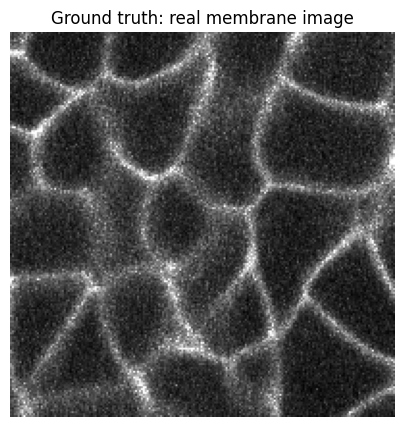

In [4]:
# Load the real membrane image from this repository
img_url = 'https://raw.githubusercontent.com/BioDecodingLab/Machine_Learning_for_Bioimage_Analysis/main/images/cells_2D.tif'
img = io.imread(img_url).astype(np.float32)
print('Full image shape:', img.shape)

# Crop a region for a tractable demo
sharp = img[300:500, 300:500]
sharp = (sharp - sharp.min()) / (sharp.max() - sharp.min())
H, W = sharp.shape

plt.figure(figsize=(5, 5))
plt.imshow(sharp, cmap='gray')
plt.title('Ground truth: real membrane image')
plt.axis('off')
plt.show()

## 3.1 Build a diffraction-limited PSF

We approximate the microscope's PSF as a 2D Gaussian, using the Rayleigh/Abbe diffraction-limit formula for the resolvable feature size (full width at half maximum, FWHM):

$$\text{FWHM} \;=\; 0.61 \, \frac{\lambda}{\mathrm{NA}}$$

for emission wavelength $\lambda$ and objective numerical aperture $\mathrm{NA}$. We assume typical values for a green fluorophore imaged with a high-NA air objective (adjust these to match your own microscope).

Diffraction-limited FWHM = 355.8 nm  ->  PSF sigma = 2.32 pixels


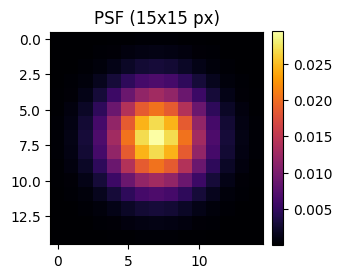

In [5]:
# Assumed (typical) optical parameters -- adjust to match your own imaging setup
wavelength_nm = 525.0    # emission wavelength (e.g. GFP), nm
NA = 0.9                 # objective numerical aperture
pixel_size_nm = 65.0      # camera pixel size projected onto the sample, nm

fwhm_nm = 0.61 * wavelength_nm / NA
sigma_px = (fwhm_nm / 2.3548) / pixel_size_nm   # FWHM -> Gaussian sigma, in pixels
print(f'Diffraction-limited FWHM = {fwhm_nm:.1f} nm  ->  PSF sigma = {sigma_px:.2f} pixels')

ksize = int(2 * round(3 * sigma_px) + 1)
ax = np.arange(ksize) - ksize // 2
xx, yy = np.meshgrid(ax, ax)
psf = np.exp(-(xx**2 + yy**2) / (2 * sigma_px**2))
psf /= psf.sum()
psf_t = torch.tensor(psf, dtype=torch.float32, device=DEVICE).view(1, 1, ksize, ksize)

def conv_psf(x):
    """Apply the (fixed, known) PSF as a convolution -- our physical forward operator."""
    return F.conv2d(x, psf_t, padding=ksize // 2)

plt.figure(figsize=(3, 3))
plt.imshow(psf, cmap='inferno')
plt.title(f'PSF ({ksize}x{ksize} px)')
plt.colorbar(fraction=0.046, pad=0.04)
plt.show()

## 3.2 Simulate the forward degradation

We convolve the real ground-truth image with the PSF, then add realistic **mixed Poisson-Gaussian noise** (photon shot noise + detector read noise), matching the noise statistics of real fluorescence cameras.

Observed (blurred + noisy) image:  PSNR = 19.94 dB   SSIM = 0.369


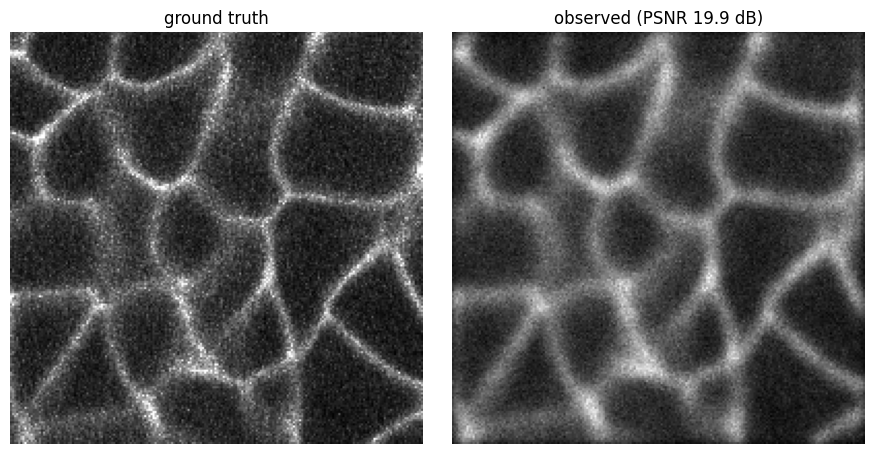

In [6]:
sharp_t = torch.tensor(sharp, device=DEVICE).view(1, 1, H, W)
blurred = conv_psf(sharp_t).cpu().numpy().squeeze()

# Mixed Poisson-Gaussian noise, calibrated to a modest photon budget (typical of live imaging)
peak_photons = 200.0
rng = np.random.default_rng(0)
photon_realization = rng.poisson(blurred * peak_photons) / peak_photons
read_noise = rng.normal(0, 0.01, size=blurred.shape)
observed = np.clip(photon_realization + read_noise, 0, None).astype(np.float32)

p_obs, s_obs = psnr(sharp, observed, data_range=1.0), ssim(sharp, observed, data_range=1.0)
print(f'Observed (blurred + noisy) image:  PSNR = {p_obs:.2f} dB   SSIM = {s_obs:.3f}')

fig, axs = plt.subplots(1, 2, figsize=(9, 4.5))
axs[0].imshow(sharp, cmap='gray'); axs[0].set_title('ground truth'); axs[0].axis('off')
axs[1].imshow(observed, cmap='gray'); axs[1].set_title(f'observed (PSNR {p_obs:.1f} dB)'); axs[1].axis('off')
plt.tight_layout(); plt.show()

# 4. Classical baseline: Richardson-Lucy deconvolution

Richardson-Lucy is the standard iterative maximum-likelihood deconvolution algorithm, assuming Poisson noise statistics and a known PSF. It's a strong classical baseline, but with no explicit regularization it tends to amplify noise (and, near image borders, produce artifacts) as iterations increase.

Richardson-Lucy (30 iterations):  PSNR = 18.48 dB   SSIM = 0.438


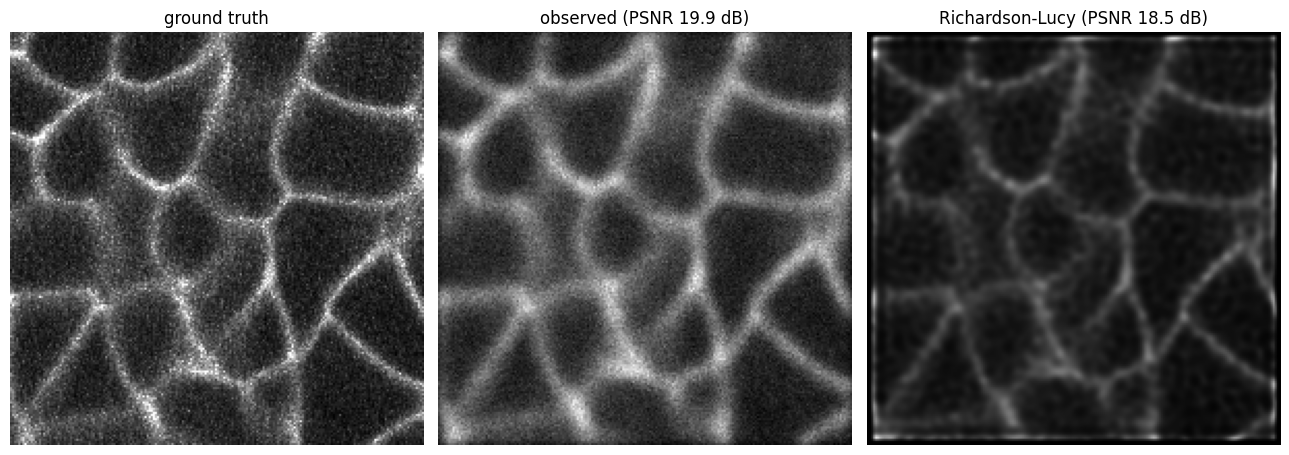

In [7]:
rl_result = richardson_lucy(observed, psf, num_iter=30, clip=False)
p_rl, s_rl = psnr(sharp, rl_result, data_range=1.0), ssim(sharp, rl_result, data_range=1.0)
print(f'Richardson-Lucy (30 iterations):  PSNR = {p_rl:.2f} dB   SSIM = {s_rl:.3f}')

fig, axs = plt.subplots(1, 3, figsize=(13, 4.5))
axs[0].imshow(sharp, cmap='gray'); axs[0].set_title('ground truth'); axs[0].axis('off')
axs[1].imshow(observed, cmap='gray'); axs[1].set_title(f'observed (PSNR {p_obs:.1f} dB)'); axs[1].axis('off')
axs[2].imshow(rl_result, cmap='gray'); axs[2].set_title(f'Richardson-Lucy (PSNR {p_rl:.1f} dB)'); axs[2].axis('off')
plt.tight_layout(); plt.show()

# 5. Physics-informed deconvolution network

Instead of representing the image as a pixel grid to be updated directly (as Richardson-Lucy does), we represent the unknown **sharp** image implicitly as a small neural network $f_\theta(x, y)$ that maps normalized pixel coordinates to intensity — a so-called **coordinate network** or **implicit neural representation**. Its training loss embeds the known optical physics directly:

$$\mathcal{L}(\theta) \;=\; \underbrace{\big\| \, \text{PSF} * f_\theta \;-\; y_{\text{observed}} \, \big\|^2}_{\text{physics-consistency / data term}} \;+\; \lambda_{TV}\underbrace{\text{TV}(f_\theta)}_{\text{edge-preserving regularizer}}$$

Unlike Richardson-Lucy, the network never sees the pixel grid updated directly by noisy data — noise can only influence it through the physical forward model, and the total-variation term keeps the solution well-posed (this is analogous to classical Tikhonov/TV-regularized deconvolution, just parameterized by a neural network instead of a pixel grid). As in the reaction-diffusion notebook, we use Fourier feature encoding to let the network represent sharp edges.

In [8]:
# Coordinates for the implicit representation
yy_c, xx_c = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')
coords = np.stack([xx_c.flatten() / W, yy_c.flatten() / H], axis=1).astype(np.float32)
coords_t = torch.tensor(coords, device=DEVICE)
observed_t = torch.tensor(observed, device=DEVICE).view(1, 1, H, W)

# Random Fourier feature encoding (fixed, non-trainable) -- lets the network represent fine detail
B_fourier = (torch.randn(2, 64) * 8.0).to(DEVICE)

def fourier_encode(x):
    x_proj = 2 * np.pi * x @ B_fourier
    return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)

class ImplicitImageNet(nn.Module):
    """Coordinate network representing the unknown sharp image, f_theta(x, y) -> intensity."""
    def __init__(self, in_dim=128, n_hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, n_hidden), nn.ReLU(),
            nn.Linear(n_hidden, n_hidden), nn.ReLU(),
            nn.Linear(n_hidden, n_hidden), nn.ReLU(),
            nn.Linear(n_hidden, 1), nn.Sigmoid()   # intensities in [0, 1], enforcing non-negativity
        )

    def forward(self, coords_encoded):
        return self.net(coords_encoded)

def total_variation(img2d):
    """Edge-preserving smoothness regularizer."""
    dx = img2d[:, :, 1:, :] - img2d[:, :, :-1, :]
    dy = img2d[:, :, :, 1:] - img2d[:, :, :, :-1]
    return dx.abs().mean() + dy.abs().mean()

deconv_model = ImplicitImageNet().to(DEVICE)
print(deconv_model)

ImplicitImageNet(
  (net): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


In [9]:
# --- Training (known PSF is fixed/non-trainable; only the image representation is optimized) ---
optimizer = torch.optim.Adam(deconv_model.parameters(), lr=2e-3)
tv_weight = 5e-4
epochs = 500

for epoch in range(epochs):
    optimizer.zero_grad()

    pred_flat = deconv_model(fourier_encode(coords_t))
    pred_img = pred_flat.view(1, 1, H, W)

    # Physics forward model: apply the KNOWN psf to the network's current estimate
    blurred_pred = conv_psf(pred_img)

    loss_data = F.mse_loss(blurred_pred, observed_t)
    loss_tv = total_variation(pred_img)
    loss = loss_data + tv_weight * loss_tv

    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f'epoch {epoch:4d} | data (physics-consistency) loss {loss_data.item():.5f} | TV loss {loss_tv.item():.4f}')

with torch.no_grad():
    deconv_result = deconv_model(fourier_encode(coords_t)).cpu().numpy().reshape(H, W)

epoch    0 | data (physics-consistency) loss 0.07093 | TV loss 0.0029


epoch  100 | data (physics-consistency) loss 0.00218 | TV loss 0.0325


epoch  200 | data (physics-consistency) loss 0.00140 | TV loss 0.0421


epoch  300 | data (physics-consistency) loss 0.00136 | TV loss 0.0452


epoch  400 | data (physics-consistency) loss 0.00134 | TV loss 0.0470


# 6. Results

Method                          PSNR (dB)   SSIM
Observed (blurred + noisy)        19.94     0.369
Richardson-Lucy (classical)       18.48     0.438
Physics-informed network          21.20     0.455


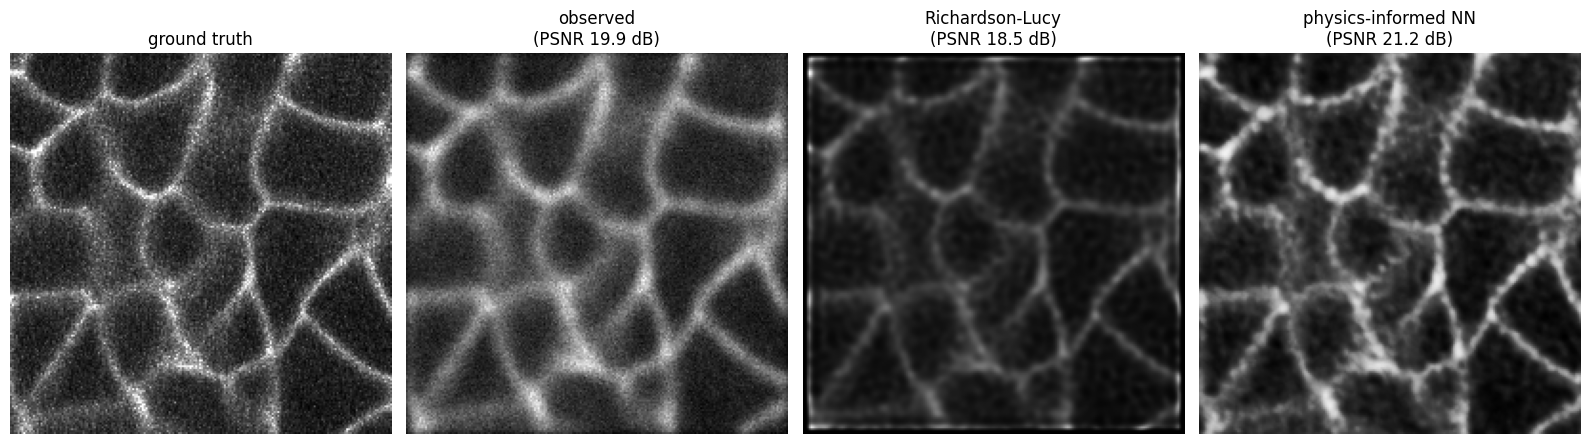

In [10]:
p_pinn, s_pinn = psnr(sharp, deconv_result, data_range=1.0), ssim(sharp, deconv_result, data_range=1.0)

print('Method                          PSNR (dB)   SSIM')
print(f'Observed (blurred + noisy)       {p_obs:6.2f}     {s_obs:.3f}')
print(f'Richardson-Lucy (classical)      {p_rl:6.2f}     {s_rl:.3f}')
print(f'Physics-informed network         {p_pinn:6.2f}     {s_pinn:.3f}')

fig, axs = plt.subplots(1, 4, figsize=(16, 4.5))
axs[0].imshow(sharp, cmap='gray'); axs[0].set_title('ground truth'); axs[0].axis('off')
axs[1].imshow(observed, cmap='gray'); axs[1].set_title(f'observed\n(PSNR {p_obs:.1f} dB)'); axs[1].axis('off')
axs[2].imshow(rl_result, cmap='gray'); axs[2].set_title(f'Richardson-Lucy\n(PSNR {p_rl:.1f} dB)'); axs[2].axis('off')
axs[3].imshow(deconv_result, cmap='gray'); axs[3].set_title(f'physics-informed NN\n(PSNR {p_pinn:.1f} dB)'); axs[3].axis('off')
plt.tight_layout(); plt.show()

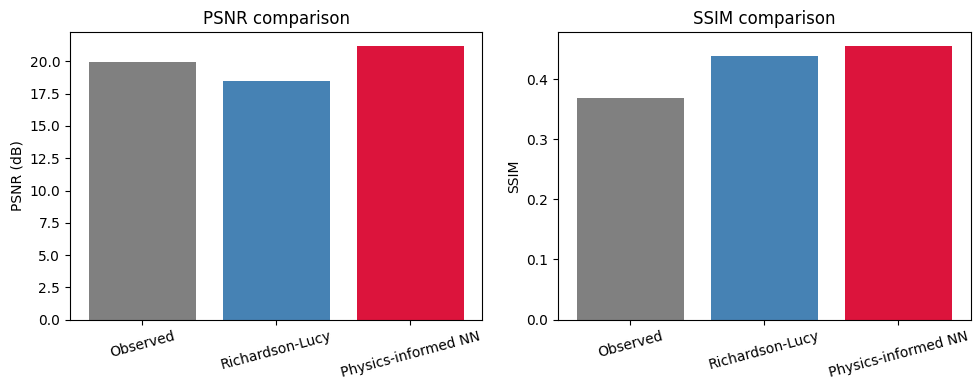

In [11]:
# Bar chart summary, in the style of the metric comparisons in notebook 2
methods = ['Observed', 'Richardson-Lucy', 'Physics-informed NN']
psnr_vals = [p_obs, p_rl, p_pinn]
ssim_vals = [s_obs, s_rl, s_pinn]

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].bar(methods, psnr_vals, color=['gray', 'steelblue', 'crimson'])
axs[0].set_ylabel('PSNR (dB)'); axs[0].set_title('PSNR comparison'); axs[0].tick_params(axis='x', rotation=15)
axs[1].bar(methods, ssim_vals, color=['gray', 'steelblue', 'crimson'])
axs[1].set_ylabel('SSIM'); axs[1].set_title('SSIM comparison'); axs[1].tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()

The physics-informed network recovers sharper cell boundaries than the raw observation and avoids the border artifacts and noise amplification visible in the unregularized Richardson-Lucy result, at both higher PSNR and higher SSIM in this example. The total-variation term is doing real work here: try setting `tv_weight = 0` and re-running to see the noise amplification return.

# 7. Challenges & Limitations

### PSF accuracy
Real PSFs are rarely perfectly Gaussian (aberrations, out-of-focus light, chromatic effects distort them) — using a mismatched PSF will bias any deconvolution method, classical or physics-informed, in the same direction.

### Known vs. blind deconvolution
This notebook assumed the PSF is known. In practice it's often only approximately known or must itself be estimated ("blind deconvolution") — a natural extension is to make the PSF (or its Gaussian sigma) a second set of trainable parameters, jointly optimized with the image, exactly as we discovered the decay length $\lambda$ in the reaction-diffusion notebook.

### Regularization strength
Like the reaction-diffusion notebook's physics-weight, `tv_weight` trades off between an overly noisy solution (too small) and an overly flattened one (too large) — always inspect the result rather than trusting a metric alone.

### Compute cost
Coordinate networks retrain from scratch for every image (unlike a CNN-based denoiser, which generalizes across images after training once). This makes them well suited to careful, single-acquisition restoration, but not to high-throughput screening pipelines.

### Clinical/quantitative caution
As in notebook 4, any deconvolved image used for downstream quantitative measurement (e.g. intensity-based colocalization) should be validated against known references — deconvolution can improve visual sharpness while still introducing bias in absolute intensity values.

# 8. To-Do: Extensions

- **Blind deconvolution**: make the PSF sigma a trainable parameter (as in Part A of the reaction-diffusion notebook) and jointly infer the PSF and the sharp image.
- **3D deconvolution**: extend to the `Multi_color_3D.tif` volume in this repository's `images/` folder, using a 3D PSF and a 3D total-variation regularizer.
- **Real PSF measurement**: replace the Gaussian approximation with a measured PSF (e.g. from sub-resolution fluorescent beads) for a real microscope.
- **Compare to notebook 2**: run both the purely data-driven autoencoder (notebook 2) and this physics-informed approach on the same degraded image, and compare when each is preferable.